In [2]:
%matplotlib inline

import os
import sys
from sys import platform

sys.path.append('../../')

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import tiktoken

import torch
import torch.nn as nn



%load_ext autoreload
%autoreload 2

from llm_from_scratch.CH4.gpt import GPTModel, generate_text_simple
from llm_from_scratch.CH2.text_data_set import create_dataloader_v1
from llm_from_scratch.CH5.loss import calc_loss_loader, calc_loss_batch
from llm_from_scratch.CH5.optim import train_model_simple
from llm_from_scratch.CH5.utils import token_ids_to_text, text_to_token_ids, generate

In [2]:
torch.manual_seed(123)

if any(x in platform for x in ('linux','win32')): 
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif platform=='darwin':  
    device=torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"{device=}")

filepath='../the-verdict.txt'
with open(filepath, 'r', encoding='utf-8') as f: text_data=f.read()

    
GPT_CONFIG_124M={'vocab_size':50257,
                 'context_length':256,
                 'emb_dim':768,
                 'n_heads':12,
                 'n_layers':12,
                 'drop_rate':0.1,
                 'qkv_bias':False}
    
tokenizer=tiktoken.get_encoding('gpt2')

train_ratio=0.9
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]
print(f"{split_idx=}, {len(train_data)=}, {len(val_data)=}")
train_loader=create_dataloader_v1(train_data, batch_size=2, max_length=GPT_CONFIG_124M['context_length'],
                                  stride=GPT_CONFIG_124M['context_length'], drop_last=True, shuffle=True, num_workers=0)
val_loader=create_dataloader_v1(val_data, batch_size=2, max_length=GPT_CONFIG_124M['context_length'], 
                                stride=GPT_CONFIG_124M['context_length'], drop_last=False, shuffle=False, num_workers=0)

model=GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs=10
train_losses, val_losses, token_seen=train_model_simple(model,train_loader=train_loader, val_loader=val_loader,
                                                        optimizer=optimizer, device=device, num_epochs=num_epochs,
                                                        eval_freq=5, eval_iter=5, start_context="Every effort moves you",
                                                        tokenizer=tokenizer)

device=device(type='mps')
split_idx=18431, len(train_data)=18431, len(val_data)=2048
Ep 1 (Step 000000): Train loss 9.817, Val loss 9.924
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.332
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.619, Val loss 7.042
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.596
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,, and,, the,, the, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss 5.524, Val loss 6.508
Ep 3 (Step 000025): Train loss 5.369, Val loss 6.378
Every effort moves you, and to the of the of the picture. Gis.                                     
Ep 4 (Step 000030): Train loss 4.830, Val loss 6.263
Ep 4 (Step 000035): Train loss 4.586, Val loss 6.285
Every effort moves you of the "I the picture.                    "I"I the picture"I had the picture"I the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.879, Val loss 6.130
Every effort

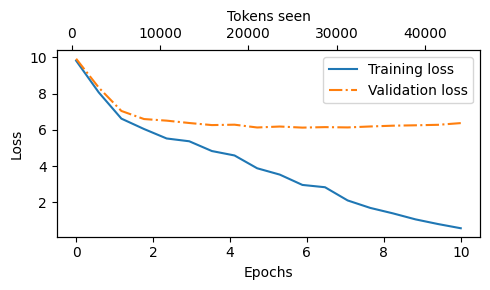

In [3]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1=plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc='upper right')
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # force the x-axis tick marks to only appears at integer values
    ax2=ax1.twiny() # create a second x-axis that shares the same y-axis. To create the second y-axis, sharing x, use twinx()
    ax2.plot(tokens_seen, train_losses, alpha=0) # invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()

epochs_tensor=torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, token_seen, train_losses, val_losses)

In [4]:
model.to("cpu").eval()
tokenizer=tiktoken.get_encoding('gpt2')
token_ids=generate_text_simple(model=model, idx=text_to_token_ids("Every effort moves you", tokenizer), max_new_tokens=25,
                               context_size=GPT_CONFIG_124M['context_length'])
print(f"output text: {token_ids_to_text(token_ids, tokenizer)}")

output text: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [5]:
torch.manual_seed(123)
tokenizer=tiktoken.get_encoding('gpt2')
token_ids=generate(model=model,idx=text_to_token_ids("Every effort moves you", tokenizer=tokenizer), 
                   max_new_tokens=15, context_size=256, top_k=25, temperature=1.4) # more uniform than sharp
print(f"output text: {token_ids_to_text(token_ids, tokenizer)}")

output text: Every effort moves you know began to go a little wild--I was such struck by holding enough


In [6]:
token_ids=generate(model=model,idx=text_to_token_ids("Every effort moves you", tokenizer=tokenizer), 
                   max_new_tokens=15, context_size=256, top_k=8, temperature=0.4) # more uniform than sharp
print(f"output text: {token_ids_to_text(token_ids, tokenizer)}")

output text: Every effort moves you?"

"Yes--quite insensible to the fact with such--


In [7]:
token_ids=generate(model=model,idx=text_to_token_ids("Every effort moves you", tokenizer=tokenizer), 
                   max_new_tokens=15, context_size=256, top_k=100, temperature=4) # more uniform than sharp
print(f"output text: {token_ids_to_text(token_ids, tokenizer)}")

output text: Every effort moves you I've discovery eighteenth goodeness?" The on smile word so felt him cheap


In [8]:
token_ids=generate(model=model,idx=text_to_token_ids("Every effort moves you", tokenizer=tokenizer), 
                   max_new_tokens=25, context_size=256, top_k=None, temperature=0) # more uniform than sharp
print(f"output text: {token_ids_to_text(token_ids, tokenizer)}")

output text: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [9]:
main_output_dirpath='../../../../../../results'
output_dirpath=f"{main_output_dirpath}/llm_from_scratch/CH5"
if not os.path.isdir(output_dirpath): os.mkdir(output_dirpath)
assert os.path.isdir(output_dirpath)

In [10]:
torch.save(model.state_dict(), os.path.join(output_dirpath, 'model.pth'))

model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load(os.path.join(output_dirpath, 'model.pth'), map_location=device))

<All keys matched successfully>

In [11]:
torch.save({"model":model.state_dict(),
            "optimizer":optimizer.state_dict()},
           os.path.join(output_dirpath, 'model_and_optimizer.pth'))

checkpoint=torch.load(os.path.join(output_dirpath, 'model_and_optimizer.pth'), map_location=device)
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint['model'])
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint['optimizer'])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [12]:
num_epochs=1
train_losses, val_losses, token_seen=train_model_simple(model,train_loader=train_loader, val_loader=val_loader,
                                                        optimizer=optimizer, device=device, num_epochs=num_epochs,
                                                        eval_freq=5, eval_iter=5, start_context="Every effort moves you",
                                                        tokenizer=tokenizer)

Ep 1 (Step 000000): Train loss 0.453, Val loss 6.475
Ep 1 (Step 000005): Train loss 0.293, Val loss 6.498
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I
